# OmniPath table ingestion

`from_omnipath` can consume an OmniPath-style interaction table
directly. This notebook uses a local table so it is deterministic.


In [1]:
import annnet as an

an.info()


Version,v0.2.0
License,BSD-3-Clause
Authors,"Youssef Zerta ✉, Daniele Bottazzi ✉, Denes Turei ✉"
Repository,https://github.com/saezlab/annnet
Documentation,https://saezlab.github.io/annnet/reference/
Default graph backend,networkx
Default plot backend,graphviz
Graph backends,✓networkx✓igraph✗graph-tool✓pyg
Plot backends,✓graphviz✗pydot✓matplotlib
Tabular data backends,✓polars✓pandas✓pyarrow
I/O modules,✓annnet✓json/ndjson✓dataframes✓csv✓excel✓graphml/gexf✓sif✓cx2✓parquet✓zarr✗sbml✓scverse✓omnipath


## Build from a local OmniPath-style table


In [2]:
import polars as pl

interactions = pl.DataFrame(
    {
        'source': ['EGF', 'EGFR', 'EGFR', 'EGFR', 'RAS', 'MEK'],
        'target': ['EGFR', 'RAS', 'RAS', 'GRB2', 'MEK', 'ERK'],
        'interaction_id': [
            'EGF_EGFR',
            'EGFR_RAS_primary',
            'EGFR_RAS_secondary',
            'EGFR_GRB2_complex',
            'RAS_MEK',
            'MEK_ERK',
        ],
        'is_directed': [True, True, True, False, True, True],
        'curation_score': [0.95, 0.88, 0.63, 0.76, 0.82, 0.79],
        'consensus_direction': [1, 1, 1, 0, 1, 1],
        'source_database': [
            'omnipath',
            'omnipath',
            'literature',
            'complexportal',
            'pathwayextra',
            'kinaseextra',
        ],
    }
)

G = an.from_omnipath(
    interactions,
    source_col='source',
    target_col='target',
    edge_id_col='interaction_id',
    directed_col='is_directed',
    weight_col='curation_score',
    edge_attr_cols=['consensus_direction', 'source_database'],
    load_vertex_annotations=False,
)

print('shape:', G.shape)
G.views.edges().select(
    ['edge_id', 'source', 'target', 'effective_weight', 'source_database']
)


[timing] fetch/receive df:     0.000s
[timing] column resolution:    0.0306s
         source='source'  target='target'  directed='is_directed'
         edge_attr_cols (2): ['consensus_direction', 'source_database']
[timing] AnnNet init:          0.025s  (pre-sized n=6 e=6)
[timing] to_rows setup:        0.000s  (6 rows, streaming=True)
[timing] bulk list build:      0.001s  (6 edges)
[timing] add_edges_bulk:       0.003s
         vertices=6  edges=6
shape: (6, 6)


edge_id,source,target,effective_weight,source_database
str,str,str,f64,str
"""EGF_EGFR""","""EGF""","""EGFR""",0.95,"""omnipath"""
"""EGFR_RAS_primary""","""EGFR""","""RAS""",0.88,"""omnipath"""
"""EGFR_RAS_secondary""","""EGFR""","""RAS""",0.63,"""literature"""
"""EGFR_GRB2_complex""","""EGFR""","""GRB2""",0.76,"""complexportal"""
"""RAS_MEK""","""RAS""","""MEK""",0.82,"""pathwayextra"""
"""MEK_ERK""","""MEK""","""ERK""",0.79,"""kinaseextra"""


## Add analysis context as slices


In [3]:
rows = list(G.views.edges().iter_rows(named=True))
edge_label = {
    row['edge_id']: f"{row['source']} -> {row['target']}"
    for row in rows
}
high_confidence = [
    row['edge_id']
    for row in rows
    if row['effective_weight'] >= 0.85
]
G.slices.add('high_confidence')
G.slices.add_edges('high_confidence', high_confidence)

print(
    'high-confidence interactions:',
    [edge_label[eid] for eid in sorted(G.slices.edges('high_confidence'))],
)


high-confidence interactions: ['EGFR -> RAS', 'EGF -> EGFR']


## Draw the prior network


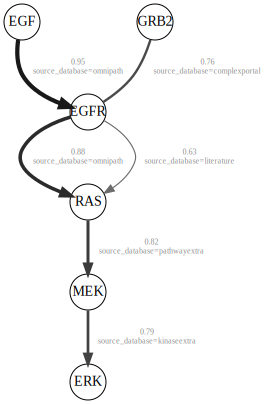

In [4]:
from annnet.utils import plotting

plotting.plot(
    G,
    backend='graphviz',
    show_edge_labels=True,
    edge_label_keys=['source_database'],
)


AnnNet can use OmniPath-style tables as prior knowledge while
keeping confidence, provenance, and downstream contexts in one
graph object.
